<a href="https://colab.research.google.com/github/ojassahu29/6DOF-Robotics-Full-Fledged-Project/blob/main/Lab6_2023A3PS0861G.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 6

## Ojas Sahu
## 2023A3PS0861G


## Import Required Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

## Load and Visualize Image (Color and Grayscale)

A color image has 3 channels (RGB), while a grayscale image has only one intensity channel.

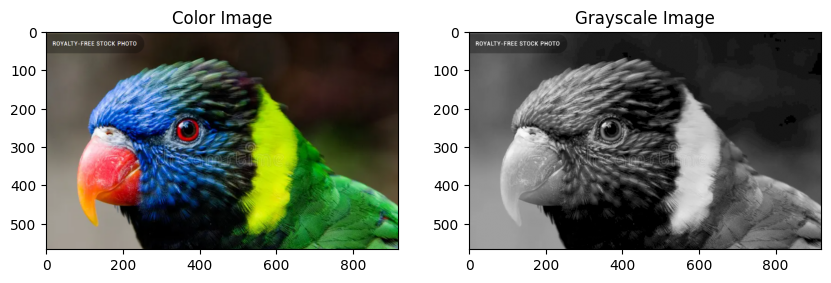

In [ ]:
img_color = cv2.imread("/content/Screenshot 2026-03-17 101629.png")
img_gray = cv2.imread("/content/Screenshot 2026-03-17 101629.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Color Image")
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("Grayscale Image")
plt.imshow(img_gray, cmap='gray')

plt.show()

## Image Data Type and Size

- Shape gives dimensions of the image
- Data type defines how pixel values are stored

In [ ]:
print("Image Shape:", img_color.shape)
print("Data Type:", img_color.dtype)
print("Image Shape:", img_gray.shape)
print("Data Type:", img_gray.dtype)

Image Shape: (567, 919, 3)
Data Type: uint8
Image Shape: (567, 919)
Data Type: uint8


## Access Pixel Intensity Values

Each pixel is accessed using (row, column).

In [ ]:
pixel_color = img_color[100,100]
pixel_gray = img_gray[100,100]

print("Color Pixel at (100,100):", pixel_color)
print("Gray Pixel at (100,100):", pixel_gray)

Color Pixel at (100,100): [ 82  93 101]
Gray Pixel at (100,100): 95


## Modify a Pixel Value

A pixel value is changed to a random intensity.

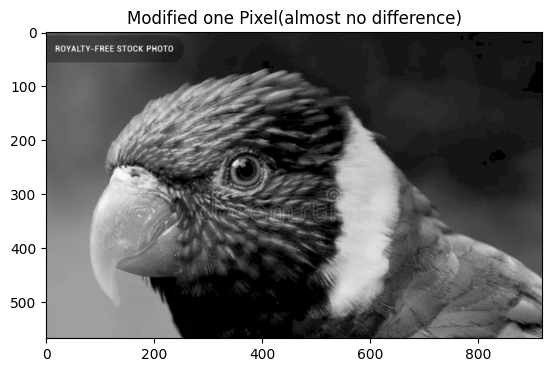

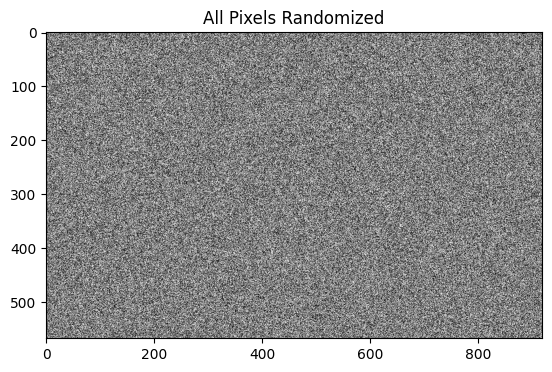

In [ ]:
img_modified = img_gray.copy()

img_modified[100,100] = random.randint(0,255)

plt.imshow(img_modified, cmap='gray')
plt.title("Modified one Pixel(almost no difference)")
plt.show()

img_random = np.random.randint(0, 256, img_gray.shape, dtype=np.uint8)

plt.imshow(img_random, cmap='gray')
plt.title("All Pixels Randomized")
plt.show()

## Histogram of Image

Histogram shows the distribution of pixel intensities.

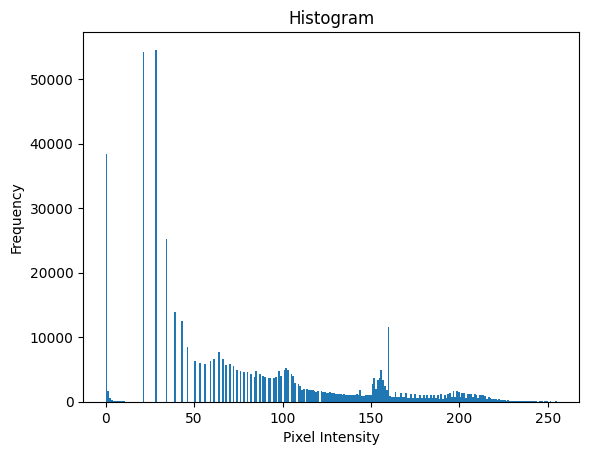

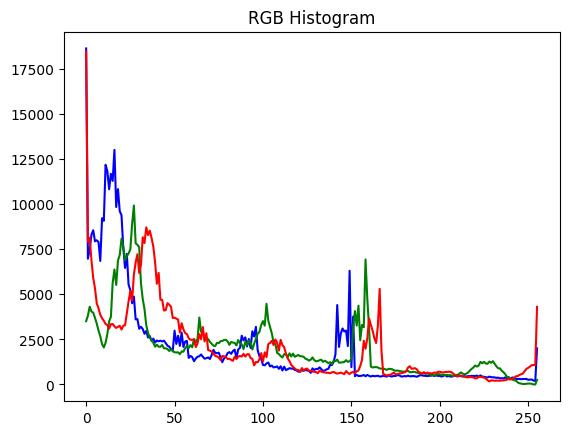

In [ ]:
plt.hist(img_gray.ravel(), bins=256)
plt.title("Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# Histogram for RGB
colors = ('b','g','r')
for i, col in enumerate(colors):
    hist = cv2.calcHist([img_color],[i],None,[256],[0,256])
    plt.plot(hist, color=col)

plt.title("RGB Histogram")
plt.show()

## Thresholding

Converts grayscale image into a binary image.

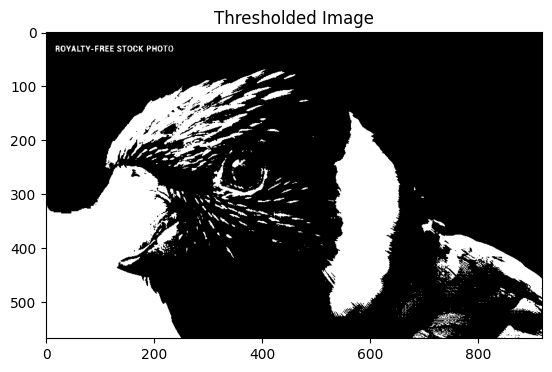

In [ ]:
ret, thresh = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.show()

## Canny Edge Detection

Detects edges by finding strong intensity gradients.

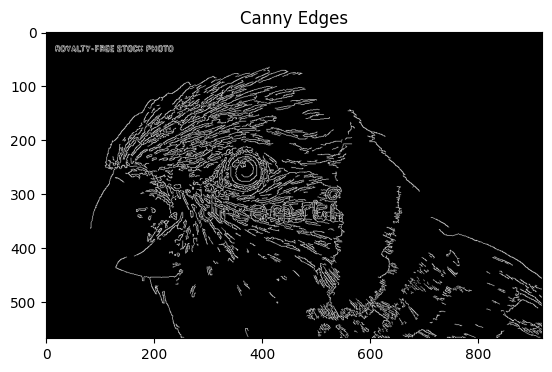

In [ ]:
edges = cv2.Canny(img_gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.show()

## Object Detection using Contours

Contours are used to detect object boundaries.

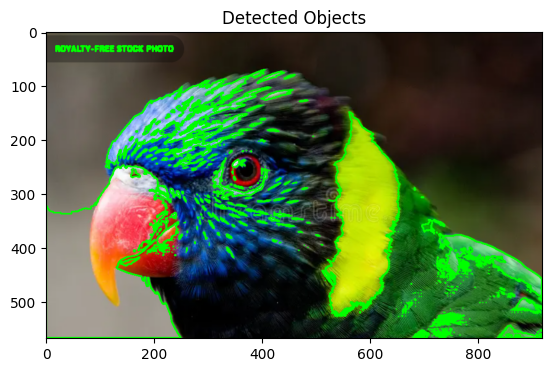

In [ ]:
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

img_contours = img_color.copy()
cv2.drawContours(img_contours, contours, -1, (0,255,0), 2)

plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.title("Detected Objects")
plt.show()

## Introducing Noise

Gaussian noise is added to simulate real-world distortions.

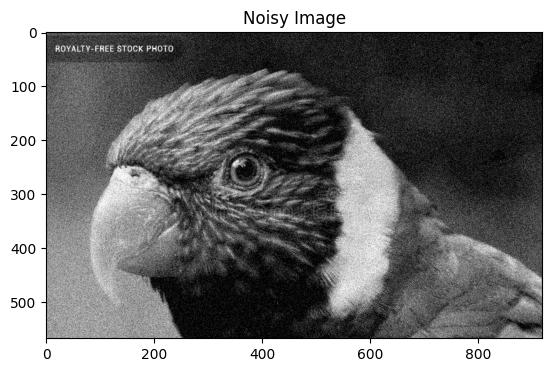

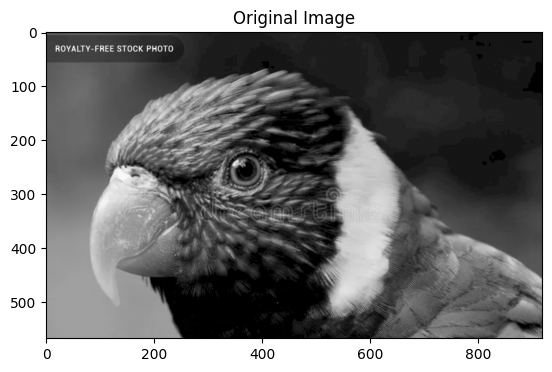

In [ ]:
mean = 0
std = 25

noise = np.random.normal(mean, std, img_gray.shape)

noisy_img = img_gray + noise
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy Image")
plt.show()

plt.imshow(img_gray, cmap='gray')
plt.title("Original Image")
plt.show()

## Gaussian Blur

Gaussian filtering is used to smooth the image and reduce noise. A Gaussian kernel is a small matrix (filter) used to blur/smooth an image.


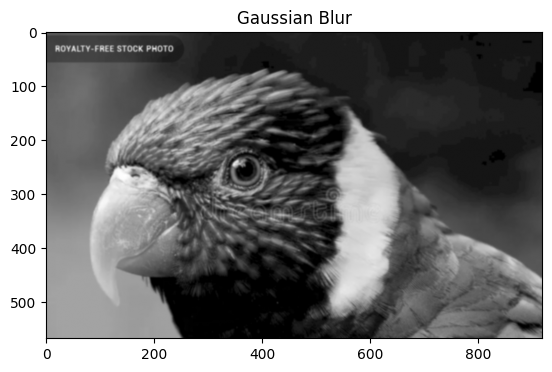

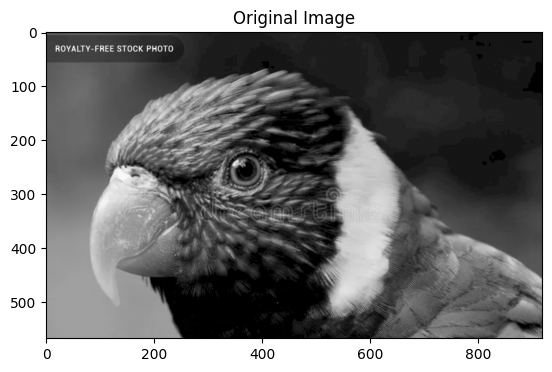

In [ ]:
gaussian = cv2.GaussianBlur(img_gray, (5,5), 0)

plt.imshow(gaussian, cmap='gray')
plt.title("Gaussian Blur")
plt.show()

plt.imshow(img_gray, cmap='gray')
plt.title("Original Image")
plt.show()

## Sobel Edge Detection

Sobel filters detect edges in horizontal and vertical directions.

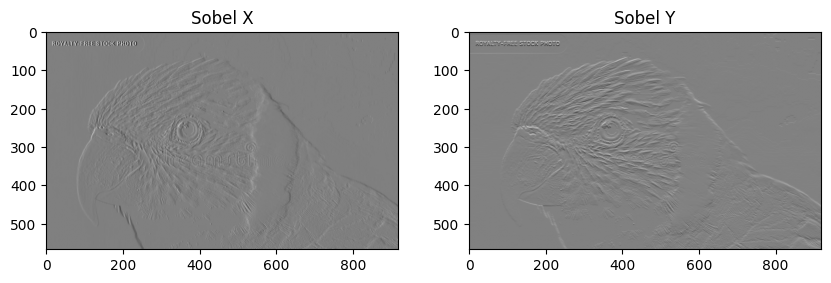

In [ ]:
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")

plt.subplot(1,2,2)
plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y")

plt.show()

## Combining Sobel Outputs

The gradient magnitude is computed using both Sobel X and Sobel Y.

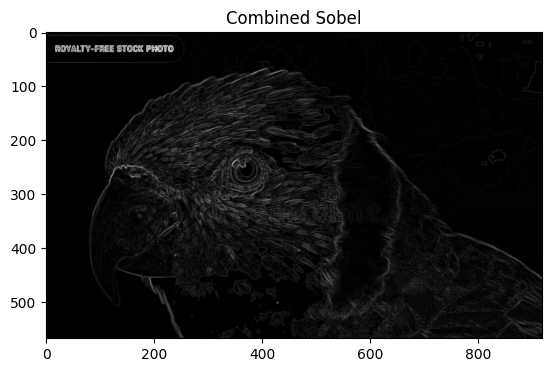

In [ ]:
sobel_combined = cv2.magnitude(sobelx, sobely)

plt.imshow(sobel_combined, cmap='gray')
plt.title("Combined Sobel")
plt.show()


## Thresholding on Edge Image

Applying threshold on Sobel output to highlight strong edges.

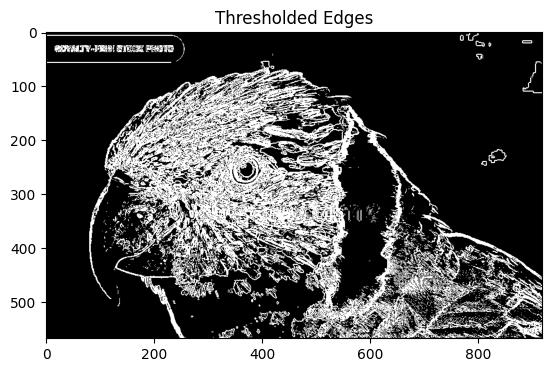

In [ ]:
ret, edge_thresh = cv2.threshold(sobel_combined.astype(np.uint8), 50, 255, cv2.THRESH_BINARY)

plt.imshow(edge_thresh, cmap='gray')
plt.title("Thresholded Edges")
plt.show()

## Relation to Convolutional Neural Networks (CNNs)

The operations performed in this lab are closely related to CNNs:

- Filters like Sobel and Gaussian are examples of convolution kernels
- In CNNs, these kernels are automatically learned instead of manually defined
- Edge detection corresponds to feature extraction in early CNN layers
- The convolution operation used here is the same as in CNN architectures

Thus, this lab demonstrates the foundational concepts behind CNNs.